# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict whether a World Bank development project will have a satisfactory outcome based on its region, sector, lending instrument, country fragility status, and approval year?

**This is a prediction (umbrella) problem because:** We are forecasting a project's evaluated outcome (Y) from characteristics observable at or near approval time (X) — we are not claiming these features *cause* a project to succeed or fail.

**The decision this enables:** A World Bank portfolio manager or donor agency can use this model to identify projects at high risk of unsatisfactory outcomes before or during implementation, enabling earlier intervention, reallocation of supervision resources, or project redesign.

**Dataset:** IEG World Bank Project Performance Ratings
- **Source:** World Bank Independent Evaluation Group (IEG) Open Data (URL: https://ieg.worldbankgroup.org/ratings)
- **N =** 12,472
- **Features =** 8 (WB Region, Country FCS Status, Agreement Type, Lending Instrument Type, Practice Group, Approval FY, Evaluation Type, Project Duration)
- **Target variable =** `Outcome` — binarized as Satisfactory (1) vs. Unsatisfactory (0), collapsing the 7-point ordinal scale into two classes
- **Access date:** April 19, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [6]:
# ============================================================
# 2.1 Load your dataset
# ============================================================

url = 'https://raw.githubusercontent.com/mcgeever1/Econ3916-Dummy-Repo/f7281f15de83c25ad5627557c2c494951b131dd5/ieg_world_bank_project_performance_ratings_04-19-2026.csv'
df = pd.read_csv(url)

# Quick look
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (12472, 21)
Columns: ['As of Date', 'Project ID', 'Project Name', 'WB Region', 'Country / Economy', 'Country / Economy Lending Group', 'Country / Economy FCS Status', 'Country / Economy FCS Lending Group', 'Practice Group', 'Global Practice', 'Agreement Type', 'Lending Instrument Type', 'Approval FY', 'Final Closing FY', 'Evaluation Type', 'Outcome', 'Quality at Entry', 'Quality of Supervision', 'Bank Performance', 'M&E Quality', 'Evaluation FY']


,As of Date,Project ID,Project Name,WB Region,Country / Economy,Country / Economy Lending Group,Country / Economy FCS Status,Country / Economy FCS Lending Group,Practice Group,Global Practice,...,Lending Instrument Type,Approval FY,Final Closing FY,Evaluation Type,Outcome,Quality at Entry,Quality of Supervision,Bank Performance,M&E Quality,Evaluation FY
0,04/17/2026,P071617,AIDS Response Project (GARFUND),Western and Central Africa,Republic of Ghana,IDA,non-FCS,IDA non-FCS,Human Development,"Health, Nutrition & Population",...,IPF,2001,2006.0,ICRR,Unsatisfactory,Unsatisfactory,Unsatisfactory,Unsatisfactory,Not Rated,2007
1,04/17/2026,P040990,CV-Energy & Water SIL (FY99),Western and Central Africa,Republic of Cabo Verde,BLEND,non-FCS,BLEND non-FCS,Infrastructure,Energy & Extractives,...,IPF,1999,2009.0,ICRR,Unsatisfactory,Unsatisfactory,Highly Unsatisfactory,Highly Unsatisfactory,Negligible,2010
2,04/17/2026,P164289,Grenada First Fiscal Resilience and Blue Growt...,Latin America and Caribbean,Grenada,BLEND,non-FCS,BLEND non-FCS,"Equitable Growth, Finance and Institutions","Macroeconomics, Trade and Investment",...,DPF,2018,2020.0,ICRR,Moderately Satisfactory,Not Rated,Not Rated,Unsatisfactory,Not Rated,2023
3,04/17/2026,P053892,Health System Development Project (TF023455),"Middle East, North Africa, Afghanistan, and Pa...",West Bank and Gaza,OTHER,non-FCS,OTHER non-FCS,Human Development,"Health, Nutrition & Population",...,IPF,2000,2005.0,ICRR,Satisfactory,Satisfactory,Satisfactory,Satisfactory,Not Rated,2006
4,04/17/2026,P007781,ECON.REC.CR.,Latin America and Caribbean,Republic of Nicaragua,IDA,non-FCS,IDA non-FCS,"Equitable Growth, Finance and Institutions","Macroeconomics, Trade and Investment",...,DPF,1992,1994.0,PPAR,Satisfactory,Satisfactory,Satisfactory,Satisfactory,Not Rated,2003


### 2.2 Basic Description

In [8]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12472 entries, 0 to 12471
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   As of Date                           12472 non-null  object 
 1   Project ID                           12472 non-null  object 
 2   Project Name                         12472 non-null  object 
 3   WB Region                            12472 non-null  object 
 4   Country / Economy                    12472 non-null  object 
 5   Country / Economy Lending Group      12375 non-null  object 
 6   Country / Economy FCS Status         12472 non-null  object 
 7   Country / Economy FCS Lending Group  12472 non-null  object 
 8   Practice Group                       7913 non-null   object 
 9   Global Practice                      7919 non-null   object 
 10  Agreement Type                       12472 non-null  object 
 11  Lending Instrument Type     

,Approval FY,Final Closing FY,Evaluation FY
count,12472.000000,7948.000000,12472.000000
mean,1996.063342,2010.852416,2004.125962
std,14.258004,8.294624,13.474267
min,1956.000000,1973.000000,1973.000000
25%,1984.000000,2004.000000,1994.000000
50%,1997.000000,2011.000000,2005.000000
75%,2008.000000,2018.000000,2016.000000
max,2024.000000,2026.000000,2026.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Practice Group                     0.365539
Global Practice                    0.365058
Final Closing FY                   0.362733
Country / Economy Lending Group    0.007777
dtype: float64


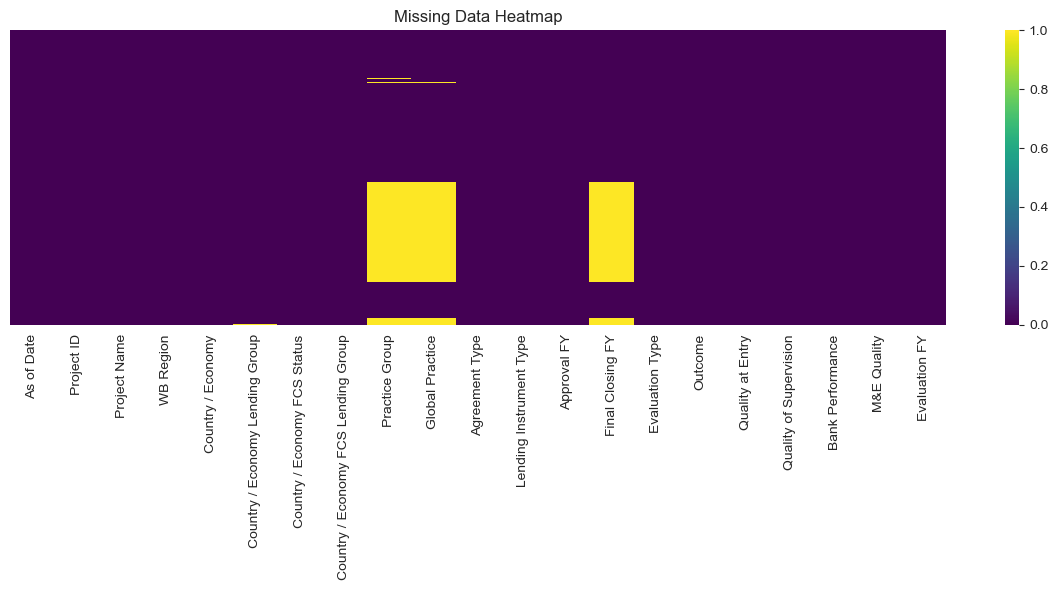

In [10]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

**Missing data strategy:** 

This is definitely MAR, likely from before the World Bank began tracking Practice and Global Groups. Rows with missing values in this column are still valuable observations of projects, and dropping them would cut the dataset by almost 40%. Because we already have Approval Year `Approval FY` & Evaluation Year `Evaluation FY` we can drop the incomplete `Final Closing FY`.

In [14]:
df = df.drop(columns=['Final Closing FY'])

In [18]:
df['Years_to_Evaluation'] = df['Evaluation FY'] - df['Approval FY']
print(f"Years_to_Evaluation: min={df['Years_to_Evaluation'].min()}, max={df['Years_to_Evaluation'].max()}, mean={df['Years_to_Evaluation'].mean():.1f}")

Years_to_Evaluation: min=1, max=31, mean=8.1


##### Shows that value starts being recorded in 1988 and is fully accounted for by 1992, with small misses later at random

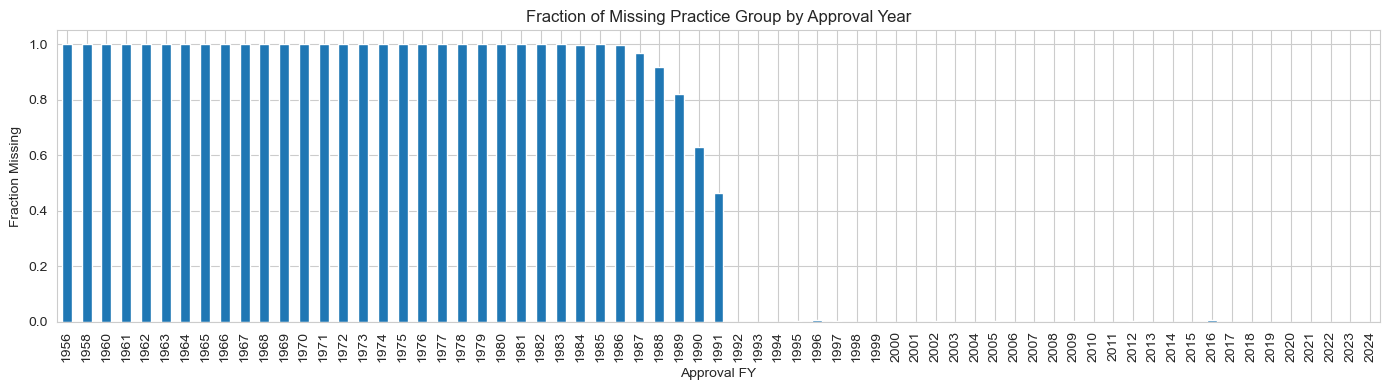

In [15]:
df['Practice_missing'] = df['Practice Group'].isnull().astype(int)
df.groupby('Approval FY')['Practice_missing'].mean().plot(kind='bar', figsize=(14,4), 
    title='Fraction of Missing Practice Group by Approval Year')
plt.ylabel('Fraction Missing')
plt.tight_layout()
plt.show()

### 2.4 Distribution Plots

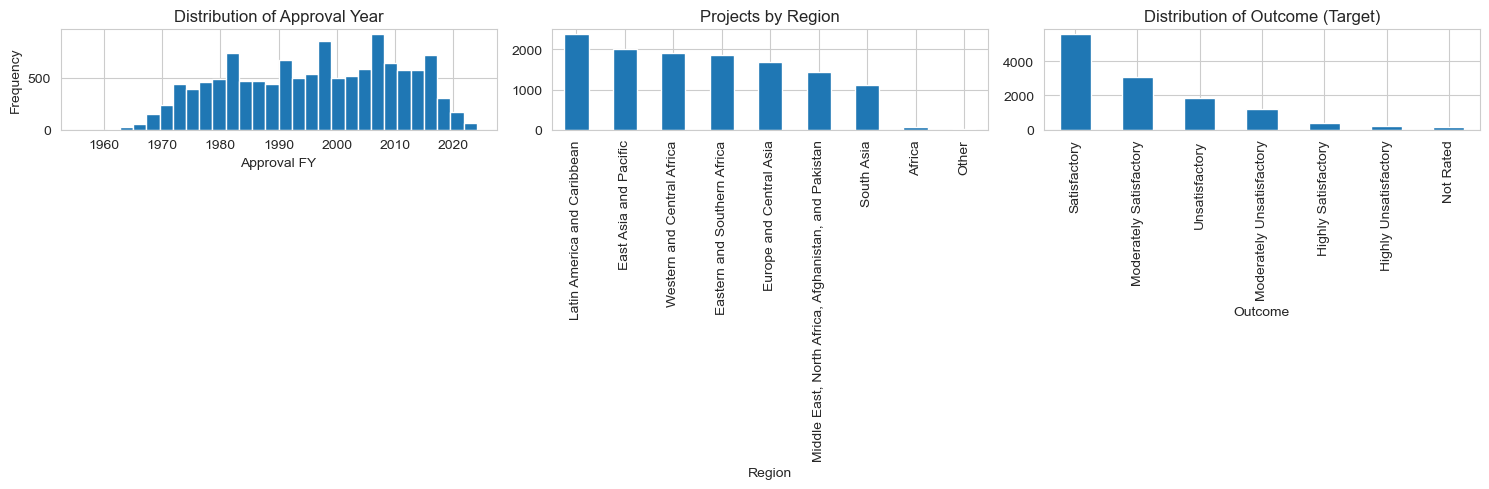

In [19]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

# # Plot distributions for your most important features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df['Approval FY'].plot(kind='hist', bins=30, ax=axes[0], title='Distribution of Approval Year')
axes[0].set_xlabel('Approval FY')

df['WB Region'].value_counts().plot(kind='bar', ax=axes[1], title='Projects by Region')
axes[1].set_xlabel('Region')

df['Outcome'].value_counts().plot(kind='bar', ax=axes[2], title='Distribution of Outcome (Target)')
axes[2].set_xlabel('Outcome')

plt.tight_layout()
plt.show()


### 2.5 Outlier Detection

In [20]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

for col in ['Approval FY', 'Evaluation FY', 'Years_to_Evaluation']:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%) | fences: [{lower:.0f}, {upper:.0f}]')

Approval FY: 0 outliers (0.0%) | fences: [1948, 2044]
Evaluation FY: 0 outliers (0.0%) | fences: [1961, 2049]
Years_to_Evaluation: 112 outliers (0.9%) | fences: [0, 16]


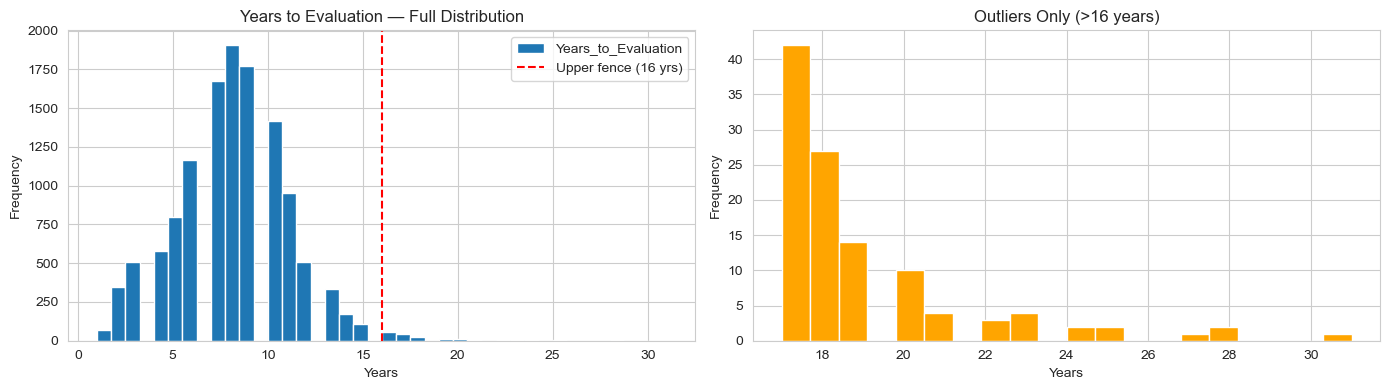

Outlier outcome breakdown:
Outcome
Satisfactory                 45
Unsatisfactory               24
Moderately Satisfactory      21
Moderately Unsatisfactory     8
Not Rated                     7
Highly Satisfactory           4
Highly Unsatisfactory         3
Name: count, dtype: int64


In [22]:
lower, upper = tukey_fences(df['Years_to_Evaluation'])
outliers = df[df['Years_to_Evaluation'] > upper]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Years_to_Evaluation'].plot(kind='hist', bins=40, ax=axes[0], title='Years to Evaluation — Full Distribution')
axes[0].axvline(upper, color='red', linestyle='--', label=f'Upper fence ({upper:.0f} yrs)')
axes[0].legend()
axes[0].set_xlabel('Years')

outliers['Years_to_Evaluation'].plot(kind='hist', bins=20, ax=axes[1], color='orange', title='Outliers Only (>16 years)')
axes[1].set_xlabel('Years')

plt.tight_layout()
plt.show()

print(f"Outlier outcome breakdown:\n{outliers['Outcome'].value_counts()}")

**Outlier strategy:**
With 112 projects with evaluation times exceeding 16 years (0.9% of total projects), outliers mark extreme edge cases in the data. While their outcome distribution is similar to the larger dataset, trimming them ensures no adverse pattern forms from old and neglected projects influencing model training. Given their small share, trimming them has negligible information loss.

### 2.6 Correlations

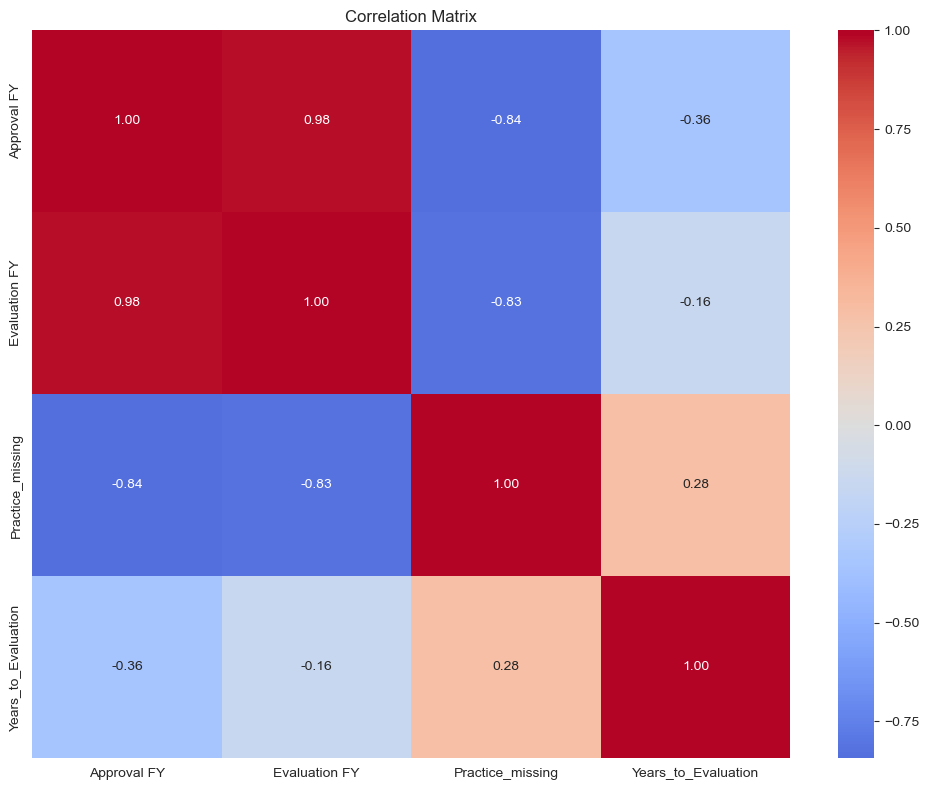

In [23]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
 
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [28]:
outcome_summary = pd.DataFrame({
    'Count': df['Outcome'].value_counts(),
    'Percent of Total': df['Outcome'].value_counts(normalize=True).round(3)*100
})
print(outcome_summary)

                           Count  Percent of Total
Outcome                                           
Satisfactory                5576              44.7
Moderately Satisfactory     3088              24.8
Unsatisfactory              1868              15.0
Moderately Unsatisfactory   1205               9.7
Highly Satisfactory          392               3.1
Highly Unsatisfactory        192               1.5
Not Rated                    151               1.2


### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* My target variable (`Outcome`) is not balanced — the majority of projects are rated Satisfactory or Moderately Satisfactory, with unrated and less satisfactory outcomes being less common.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* Approval and Evaluation FY are highly correlated, indicating multicollinearity. Because Approval Fiscal Year captures pre-project characteristics, it will stay and Evaluation FY will be dropped before modeling.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest data problem EDA has uncovered is the almost 40% missing values for Practice and Global Practice Groups, driven by the World Bank's internal classification system not being applied to projects approved before 1992. This is Missing-At-Random, and as such does not require row removal — missing values will be imputed as "Unknown" to retain 40% of the dataset.

In [30]:
print(f"Total: {len(df)}")
print(f"Before 1992: {len(df[df['Approval FY'] < 1992])}")
print(f"1992 and after: {len(df[df['Approval FY'] >= 1992])}")

Total: 12472
Before 1992: 4821
1992 and after: 7651


In [25]:
# drop 
df = df.drop(columns=['Evaluation FY'])

#### Investment Project Financing vs Development Policy Fianancing

In [32]:
df.groupby('Lending Instrument Type')['Outcome'].apply(
    lambda x: (x.isin(['Satisfactory', 'Moderately Satisfactory', 'Highly Satisfactory'])).mean() * 100
).round(1).rename('% Satisfactory')



Lending Instrument Type
DPF    74.1
IPF    72.4
Name: % Satisfactory, dtype: float64

#### By Region

In [36]:
print(df.groupby('WB Region')['Outcome'].apply(
    lambda x: (x.isin(['Satisfactory', 'Moderately Satisfactory', 'Highly Satisfactory'])).mean() * 100
).round(1).sort_values().to_string())


WB Region
Other                                                   42.9
Africa                                                  53.6
Western and Central Africa                              64.7
Eastern and Southern Africa                             65.3
Middle East, North Africa, Afghanistan, and Pakistan    71.4
Latin America and Caribbean                             73.3
South Asia                                              75.6
Europe and Central Asia                                 78.4
East Asia and Pacific                                   81.0


In [37]:
print(df.groupby('Country / Economy FCS Status')['Outcome'].apply(
    lambda x: (x.isin(['Satisfactory', 'Moderately Satisfactory', 'Highly Satisfactory'])).mean() * 100
).round(1).to_string())


Country / Economy FCS Status
FCS        70.5
non-FCS    72.8


#### By Country (top and bottom 7)

In [39]:
country_counts = df.groupby('Country / Economy')['Outcome'].count()
country_sat = df.groupby('Country / Economy')['Outcome'].apply(
    lambda x: (x.isin(['Satisfactory', 'Moderately Satisfactory', 'Highly Satisfactory'])).mean() * 100
).round(1)

filtered = country_sat[country_counts >= 20].sort_values()

print("Bottom 7 (min 20 projects):")
print(filtered.head(7).to_string())
print("\nTop 7 (min 20 projects):")
print(filtered.tail(7).to_string())

Bottom 7 (min 20 projects):
Country / Economy
Democratic Republic of Timor-Leste         39.3
Democratic Republic of the Congo           45.5
Somali Democratic Republic                 47.4
Republic of Congo                          50.0
People's Democratic Republic of Algeria    50.7
Republica Bolivariana de Venezuela         51.4
Republic of Chad                           51.5

Top 7 (min 20 projects):
Country / Economy
Republic of Nicaragua             90.0
Republic of Korea                 90.5
Socialist Republic of Viet Nam    90.6
People's Republic of China        90.7
Republic of Latvia                90.9
Republic of Serbia                91.7
Republic of Kosovo                94.4


### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 12472** observations and **M = 8** features (after engineering and dropping).

**Missing data:** 36.5% of `Practice Group` & `Global Practice` cells are missing. The missingness pattern appears to be MAR, confirmed by a year-by-year plot showing 100% missingness for all 4,821 projects approved before 1992, and 0% missing for the 7,651 projects approved after 1992. The World Bank did not apply its current practice classification system to older projects. Missing values are imputed with "Unknown" to retain all 12,472 observations.

**Outliers:** I identified **112 outliers (0.9%)** using Tukey Fences. These were trimmed as they represent extreme edge cases outside the typical project lifecycle, with negligible impact on dataset size.

**Target variable:** Outcome is imbalanced across 7 categories. The two largest classes are Satisfactory (44.7%) and Moderately Satisfactory (24.8%), with Unsatisfactory at 15.0% and Moderately Unsatisfactory at 9.7%. After binarizing into Satisfactory (1) vs. Unsatisfactory (0), stratified train/test splitting will be used to preserve class proportions.

**Key finding from EDA:** WB Region shows the strongest variation in outcome rates, even stronger when looking at individual countries within regions. Africa sees the lowest satisfactory outcomes at only 53.6%, while East Asia and Pacific see 81%. This is expected to be the most impactful feature in future ML modeling. 

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [ ]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Binarize target: Satisfactory=1, Unsatisfactory=0
sat_labels = ['Satisfactory', 'Moderately Satisfactory', 'Highly Satisfactory']
df_model = df[df['Outcome'] != 'Not Rated'].copy()
df_model['target'] = df_model['Outcome'].apply(lambda x: 1 if x in sat_labels else 0)

# Impute missing categoricals with 'Unknown'
for col in ['Practice Group', 'Global Practice', 'Country / Economy Lending Group']:
    df_model[col] = df_model[col].fillna('Unknown')

# Trim outliers in Years_to_Evaluation
df_model = df_model[df_model['Years_to_Evaluation'] <= 16]

# Select features
features = ['WB Region', 'Lending Instrument Type', 'Agreement Type',
            'Practice Group', 'Country / Economy FCS Status',
            'Approval FY', 'Years_to_Evaluation']

X = pd.get_dummies(df_model[features])
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Class balance (train): {y_train.mean():.2%} satisfactory')

### 3.2 Model 1: Baseline

In [ ]:
# ============================================================
# 3.2 Model 1 — Baseline: Logistic Regression
# ============================================================
from sklearn.linear_model import LogisticRegression

model_1 = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print('Model 1: Logistic Regression')
print(classification_report(y_test, y_pred_1))

### 3.3 Model 2: Your Choice

In [ ]:
# ============================================================
# 3.3 Model 2 — Your choice (Final submission only)
# ============================================================
# from sklearn.ensemble import RandomForestClassifier
# 
# model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
# model_2.fit(X_train, y_train)
# y_pred_2 = model_2.predict(X_test)
# print('Model 2: Random Forest')
# print(classification_report(y_test, y_pred_2))

### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15) — Final submission only
# ============================================================
# scoring = 'accuracy'
# cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
# cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
# print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
# print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
# 
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
# 
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
# 
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___